In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [68]:
df = pd.read_csv('OrderDetails_2026_01_15-2026_07_15.csv')

# This export is two report chunks concatenated together: the header row repeats mid-file and the
# two chunks' date ranges overlap by part of a day, producing exact-duplicate order rows. That
# stray header row (a literal 'Opened' value in the Opened column) is also why every column below
# loaded as string instead of numeric -- clean both before anything else.
df = df[df['Opened'] != 'Opened'].copy()
duplicate_rows = df.duplicated().sum()
print(f'Exact duplicate rows from overlapping export chunks: {duplicate_rows}')
df = df.drop_duplicates()

numeric_cols = ['# of Guests', 'Discount Amount', 'Amount', 'Tip', 'Gratuity', 'Total']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.info()
df.head(10)
df = df[df['Amount'] > 0]

# Amount is already net of any Discount Amount (confirmed: rows with a nonzero discount still
# have Total > 0 even when Discount == Amount, which is only consistent with Amount being the
# post-discount charge) -- so VPCPM/TPCPM below are built on realized revenue, not list price.
# Tip/Gratuity/Total/Discount Amount aren't used in any metric; they're kept numeric for
# reference (e.g. spot-checking a specific order) but don't feed VPCPM/TPCPM.

# Guest counts up to 18 form a smooth, decreasing tail (consistent with legitimate large
# combined-table bookings); a single row at 101 guests on a 1-seat bar stool has no such
# support and is almost certainly a data-entry error, not a real party. Flag and exclude it
# rather than letting it silently blow out every chart's x-axis and party-size aggregate.
GUEST_COUNT_SANITY_MAX = 20
implausible_guests = df[df['# of Guests'] > GUEST_COUNT_SANITY_MAX]
print(f'\nExcluding {len(implausible_guests)} row(s) with implausible guest counts (> {GUEST_COUNT_SANITY_MAX}):')
print(implausible_guests[['Opened', 'Table', '# of Guests', 'Amount']])
df = df[df['# of Guests'] <= GUEST_COUNT_SANITY_MAX]

# BD4 is no longer an active table, but this export spans 7 months so its historical orders are
# still present. Excluded entirely (not just from capacity checks) since it's not actionable for
# any current seating decision.
bd4_rows = (df['Table'] == 'BD4').sum()
print(f'\nExcluding {bd4_rows} row(s) from BD4 (retired table, no longer in service).')
df = df[df['Table'] != 'BD4']

Exact duplicate rows from overlapping export chunks: 20
<class 'pandas.DataFrame'>
Index: 6609 entries, 0 to 6629
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Opened                     6609 non-null   str    
 1   # of Guests                6609 non-null   int64  
 2   Table                      6233 non-null   str    
 3   Discount Amount            6609 non-null   float64
 4   Amount                     6609 non-null   float64
 5   Tip                        6609 non-null   float64
 6   Gratuity                   6609 non-null   float64
 7   Total                      6609 non-null   float64
 8   Closed                     6572 non-null   str    
 9   Duration (Opened to Paid)  6600 non-null   str    
dtypes: float64(5), int64(1), str(4)
memory usage: 568.0 KB

Excluding 1 row(s) with implausible guest counts (> 20):
               Opened Table  # of Guests  Amount
710  1/31/26 1

In [69]:
df['Amount'].sort_values(ascending=False)


13      5127.09
3762    4704.00
780     2400.00
6136    2298.85
5926    2200.00
         ...   
1018       3.00
651        1.00
3761       1.00
6569       0.01
5486       0.01
Name: Amount, Length: 6233, dtype: float64

In [70]:
def get_section(table):
    if pd.isna(table):
        return 'Unknown/To-Go'
    if table.startswith('BD'):
        return 'Black Duck'
    if table.startswith('B'):
        return 'Bar'
    if table.startswith('E'):
        return 'Evangeline'
    if table.startswith('O'):
        return 'Open Lounge'
    return 'Unknown'

df['Section'] = df['Table'].map(get_section)


In [71]:
opened_dt = pd.to_datetime(df['Opened'], format='%m/%d/%y %I:%M %p')
closed_dt = pd.to_datetime(df['Closed'], format='%m/%d/%y %I:%M %p')

df.insert(0, 'Date', opened_dt.dt.strftime('%m/%d/%y'))

# Use Toast's own Duration (Opened to Paid) rather than Closed - Opened: Closed frequently reflects
# a late/batch POS close-out, not actual guest departure, which inflates the timestamp-diff version
# (e.g. rows sitting open for hours or days). Duration (Opened to Paid) is a 'H:MM:SS' string.
df['Duration'] = pd.to_timedelta(df['Duration (Opened to Paid)']).dt.total_seconds() / 60  # minutes
df['Duration'].info()

# How much does the Duration >= 15min floor censor each section? Bar is walk-up/quick-turnover,
# so this filter is expected to drop a disproportionate share of Bar rows -- worth knowing before
# trusting any section's stats, especially Bar's (see the context-only summary at the end).
pre_counts = df['Section'].value_counts()
df = df[df['Duration'] >= 15]
post_counts = df['Section'].value_counts()
drop_summary = pd.DataFrame({
    'Before': pre_counts,
    'After': post_counts.reindex(pre_counts.index).fillna(0).astype(int),
})
drop_summary['Dropped'] = drop_summary['Before'] - drop_summary['After']
drop_summary['Drop %'] = (100 * drop_summary['Dropped'] / drop_summary['Before']).round(1)
drop_summary.sort_values('Drop %', ascending=False)

<class 'pandas.Series'>
Index: 6233 entries, 0 to 6629
Series name: Duration
Non-Null Count  Dtype  
--------------  -----  
6224 non-null   float64
dtypes: float64(1)
memory usage: 97.4 KB


,Before,After,Dropped,Drop %
Section,,,,
Unknown/To-Go,260,87,173,66.5
Bar,2463,1965,498,20.2
Black Duck,552,545,7,1.3
Open Lounge,2530,2508,22,0.9
Evangeline,428,425,3,0.7


In [72]:
df['Opened'] = opened_dt.dt.strftime('%I:%M %p')
df['Closed'] = closed_dt.dt.strftime('%I:%M %p')

df.head(10)


,Date,Opened,# of Guests,Table,Discount Amount,Amount,Tip,Gratuity,Total,Closed,Duration (Opened to Paid),Section,Duration
0,01/15/26,04:05 PM,2,O3,0.0,94.0,30.0,0.0,132.57,05:25 PM,1:14:12,Open Lounge,74.200000
1,01/15/26,04:24 PM,2,O6,0.0,127.0,0.0,0.0,138.62,06:10 PM,1:45:53,Open Lounge,105.883333
2,01/15/26,04:52 PM,2,B7,0.0,130.0,0.0,0.0,141.86,06:54 PM,2:02:29,Bar,122.483333
4,01/15/26,04:58 PM,1,B12,0.0,57.0,0.0,0.0,62.22,05:27 PM,0:29:35,Bar,29.583333
5,01/15/26,05:34 PM,2,O2,0.0,133.0,0.0,0.0,145.16,07:17 PM,1:43:42,Open Lounge,103.700000
6,01/15/26,05:41 PM,4,O5,0.0,119.0,23.8,0.0,153.63,07:14 PM,1:23:01,Open Lounge,83.016667
7,01/15/26,05:25 PM,1,B4,0.0,10.0,0.0,0.0,10.92,05:43 PM,0:17:52,Bar,17.866667
8,01/15/26,05:40 PM,4,O9,0.0,297.0,60.0,0.0,384.15,07:40 PM,1:38:20,Open Lounge,98.333333
9,01/15/26,05:57 PM,2,B12,0.0,51.0,5.0,0.0,60.66,12:56 AM,1:11:51,Bar,71.850000
16,01/16/26,04:11 PM,2,B11,0.0,262.0,0.0,0.0,285.96,12:35 AM,3:31:23,Bar,211.383333


# Value per Person per 15 Minutes


In [73]:
# VPCPM is stored on the raw dollar scale for display, plus a log-scale column (LogVPCPM) used
# for the mean/variance math -- $/guest/15min is right-skewed, and a log-normal assumption is
# what makes mean/SEM/shrinkage math valid. Aggregates below are always back-transformed to
# dollars via exp(mean of logs) -- the geometric mean -- rather than shown in raw log units.
df['VPCPM'] = (df['Amount'] / df['# of Guests']) / (df['Duration'] / 15)
df['LogVPCPM'] = np.log(df['VPCPM'])
df[['VPCPM', 'LogVPCPM']].head(10)


,VPCPM,LogVPCPM
0,9.501348,2.251434
1,8.995750,2.196752
2,7.960267,2.074463
4,28.901408,3.363890
5,9.619094,2.263750
6,5.375427,1.681838
7,8.395522,2.127699
8,11.326271,2.427125
9,5.323591,1.672148
16,9.295908,2.229574


In [74]:
# Exclude Unknown/To-Go orders (Table is NaN) from the pooled party-size trend: Duration for these
# reflects a POS timestamp artifact rather than real seated-table turnover -- e.g. a private-event
# check for $7000 miscoded as 1 guest with a 66-second "duration" -- which would otherwise distort
# the party-size-1 bucket below.
seated_df = df[df['Section'] != 'Unknown/To-Go']

geo_mean_vpcpm = np.exp(seated_df.groupby('# of Guests')['LogVPCPM'].mean())
geo_mean_vpcpm.reset_index().rename(columns={'LogVPCPM': 'Geometric Mean VPCPM ($)'})

,# of Guests,Geometric Mean VPCPM ($)
0,1,8.920856
1,2,7.590912
2,3,6.209824
3,4,5.983150
4,5,5.556095
5,6,5.489533
6,7,4.700451
7,8,4.586536
8,9,4.798843
9,10,4.438674


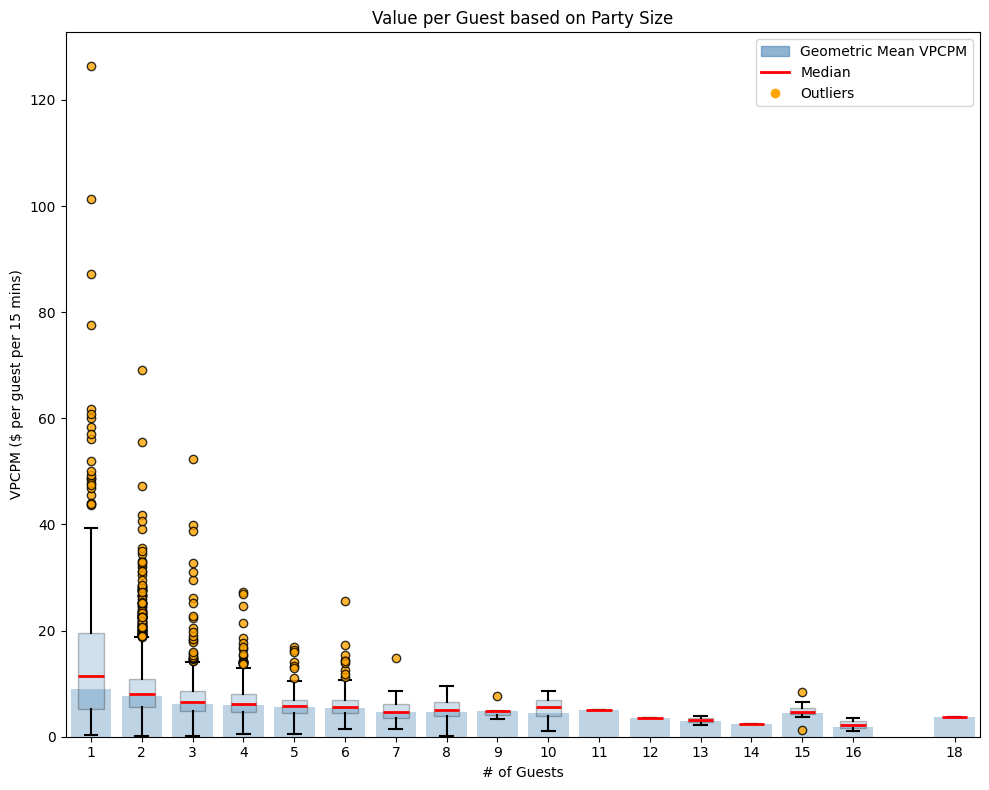

In [75]:
mean_log_vpcpm = seated_df.groupby('# of Guests')['LogVPCPM'].mean()
geo_mean_vpcpm = np.exp(mean_log_vpcpm)
guest_sizes = sorted(seated_df['# of Guests'].unique())
groups = [seated_df[seated_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(geo_mean_vpcpm.index, geo_mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)

ax.boxplot(groups, positions=guest_sizes, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.25),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5),
           zorder=2)

ax.set_xticks(guest_sizes)
ax.set_xlabel('# of Guests')
ax.set_ylabel('VPCPM ($ per guest per 15 mins)')
ax.set_title('Value per Guest based on Party Size')

handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', alpha=0.6),
    plt.Line2D([0], [0], color='red', linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8),
]
ax.legend(handles, ['Geometric Mean VPCPM', 'Median', 'Outliers'], loc='best')
plt.tight_layout()
plt.show()

## Who Spends More Per Hour? — Descriptive Analysis by Party Size


## Seating Sections & Capacity

Splitting `Table` into its section (Bar, Black Duck, Evangeline, Open Lounge) and attaching each table's confirmed seat range (`Capacity_Min`/`Capacity_Max`), so value-per-party-size can be compared *within* a section instead of pooled across very different seating types (a 1-seat bar stool behaves nothing like a 5-top).

All capacities below are confirmed (no longer inferred): `B1`-`B12` seat 1 each (`B13`/`B14` are standing-wait placeholders, not real seats, excluded from capacity-based checks but still counted in Bar's revenue reference). Black Duck runs `BD1` (2), `BD2` (2-3), `BD3` (3-4), and `BD5` (2) — `BD5` is **not** retired, it carries a comparable order volume to `BD2`/`BD3` in this data. `BD4` *is* retired (its historical orders are excluded entirely earlier in the notebook, not just from capacity checks). Evangeline: `E1`/`E2` seat 2 each, `E3` flexes 5-6. Open Lounge: `O1` and `O8` seat 3; every other table, including `O10`, seats 2.


In [76]:
CAPACITY_RANGES = {}
CAPACITY_RANGES.update({f'B{i}': (1, 1) for i in range(1, 13)})  # B13/B14 excluded: standing-wait placeholders, not real seats

CAPACITY_RANGES.update({
    'BD1': (2, 2),
    'BD2': (2, 3),
    'BD3': (3, 4),
    'BD5': (2, 2),  # active, not retired -- comparable order volume to BD2/BD3 in this data
    'E1': (2, 2),
    'E2': (2, 2),
    'E3': (5, 6),
    'O1': (3, 3),
    'O8': (3, 3),
})
CAPACITY_RANGES.update({f'O{i}': (2, 2) for i in range(1, 11) if f'O{i}' not in CAPACITY_RANGES})

df['Capacity_Min'] = df['Table'].map(lambda t: CAPACITY_RANGES.get(t, (np.nan, np.nan))[0])
df['Capacity_Max'] = df['Table'].map(lambda t: CAPACITY_RANGES.get(t, (np.nan, np.nan))[1])
df[['Table', 'Section', 'Capacity_Min', 'Capacity_Max']].drop_duplicates().sort_values(['Section', 'Table'])


,Table,Section,Capacity_Min,Capacity_Max
67,B1,Bar,1.0,1.0
31,B10,Bar,1.0,1.0
16,B11,Bar,1.0,1.0
4,B12,Bar,1.0,1.0
125,B13,Bar,NaN,NaN
113,B14,Bar,NaN,NaN
19,B2,Bar,1.0,1.0
42,B3,Bar,1.0,1.0
7,B4,Bar,1.0,1.0
43,B5,Bar,1.0,1.0


In [77]:
unassigned = df[df['Capacity_Max'].isna() & df['Table'].notna()]
print('Tables with no capacity assigned (excluded from capacity-based analysis):')
print(unassigned['Table'].value_counts())

# Toast records one table per order -- when staff combine tables for a large party or event, the
# whole check lands on a single "anchor" table with no trace of the other tables that were
# actually used (confirmed against Toast's Orders API: a check has exactly one table reference,
# and combining checks moves items onto one destination check). So `# of Guests > Capacity_Max`
# doesn't mean bad data -- for Black Duck/Evangeline/Open Lounge it's usually a real multi-table
# booking misattributed to one table; for Bar it's usually just a routine 2-top on a 1-seat stool.
# This flag is used further down to split multi-table bookings out of the single-table,
# per-seat VPCPM analysis rather than letting them dilute it. See README for more detail --
# this is a known open issue, not something fixed here, since it needs a Toast-side or
# process-level fix (see conversation/backlog) to actually resolve.
df['Likely_Combined_Booking'] = df['# of Guests'] > df['Capacity_Max']

overbooked = df[df['Likely_Combined_Booking']]
print(f'\nRows exceeding assigned max capacity ({len(overbooked)}):')
overbooked[['Table', 'Section', 'Capacity_Min', 'Capacity_Max', '# of Guests', 'Amount']]


Tables with no capacity assigned (excluded from capacity-based analysis):
Table
B14    35
B13    15
Name: count, dtype: int64

Rows exceeding assigned max capacity (2650):


,Table,Section,Capacity_Min,Capacity_Max,# of Guests,Amount
2,B7,Bar,1.0,1.0,2,130.0
6,O5,Open Lounge,2.0,2.0,4,119.0
8,O9,Open Lounge,2.0,2.0,4,297.0
9,B12,Bar,1.0,1.0,2,51.0
16,B11,Bar,1.0,1.0,2,262.0
...,...,...,...,...,...,...
6619,B4,Bar,1.0,1.0,2,16.0
6622,BD2,Black Duck,2.0,3.0,7,126.0
6623,B2,Bar,1.0,1.0,2,67.0
6625,B6,Bar,1.0,1.0,2,54.0


## Bar vs. Table Seating

The bar (12 single-guest stools, no reservations) and the table sections (Black Duck, Evangeline, Open Lounge — where reservations actually happen) serve very different party-size ranges and different business decisions, so VPCPM is plotted separately for each rather than pooled. The reservation-relevant sections get the shrinkage/LOOCV treatment below; Bar gets its own context-only summary further down.


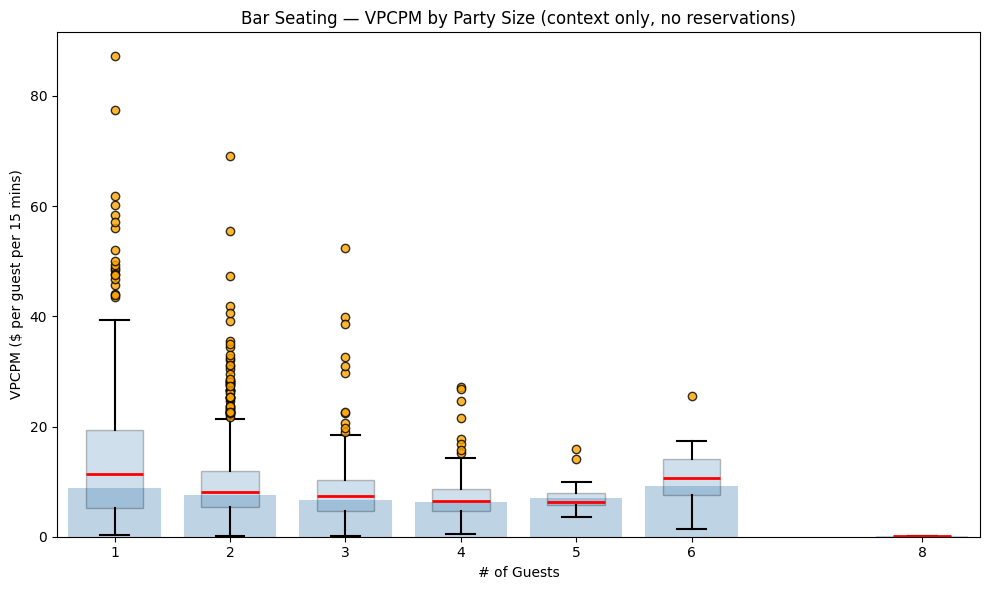

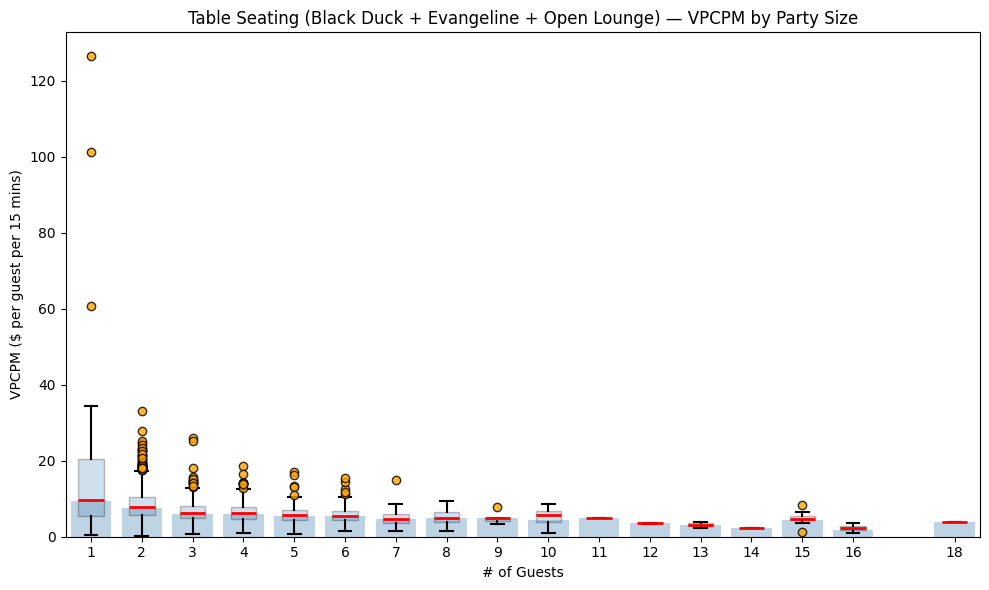

In [78]:
def plot_vpcpm_by_party_size(sub_df, title):
    geo_mean_vpcpm = np.exp(sub_df.groupby('# of Guests')['LogVPCPM'].mean())
    guest_sizes = sorted(sub_df['# of Guests'].unique())
    groups = [sub_df[sub_df['# of Guests'] == g]['VPCPM'].values for g in guest_sizes]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(geo_mean_vpcpm.index, geo_mean_vpcpm, alpha=0.35, color='steelblue', zorder=1)
    ax.boxplot(groups, positions=guest_sizes, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.25),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, alpha=0.8),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               zorder=2)
    ax.set_xticks(guest_sizes)
    ax.set_xlabel('# of Guests')
    ax.set_ylabel('VPCPM ($ per guest per 15 mins)')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

bar_df = df[df['Section'] == 'Bar']
table_df = df[df['Section'].isin(['Black Duck', 'Evangeline', 'Open Lounge'])]

plot_vpcpm_by_party_size(bar_df, 'Bar Seating — VPCPM by Party Size (context only, no reservations)')
plot_vpcpm_by_party_size(table_df, 'Table Seating (Black Duck + Evangeline + Open Lounge) — VPCPM by Party Size')


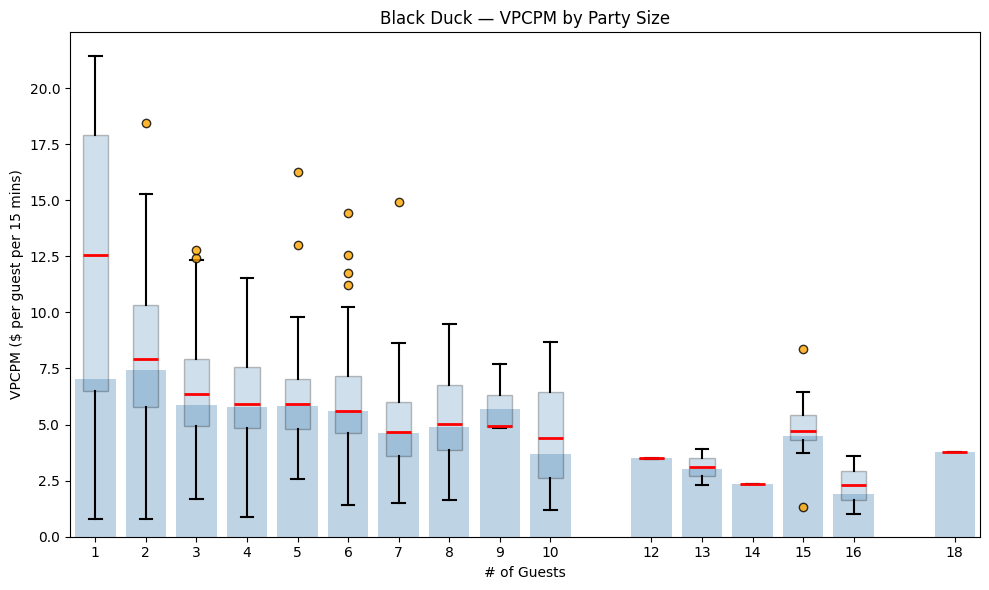

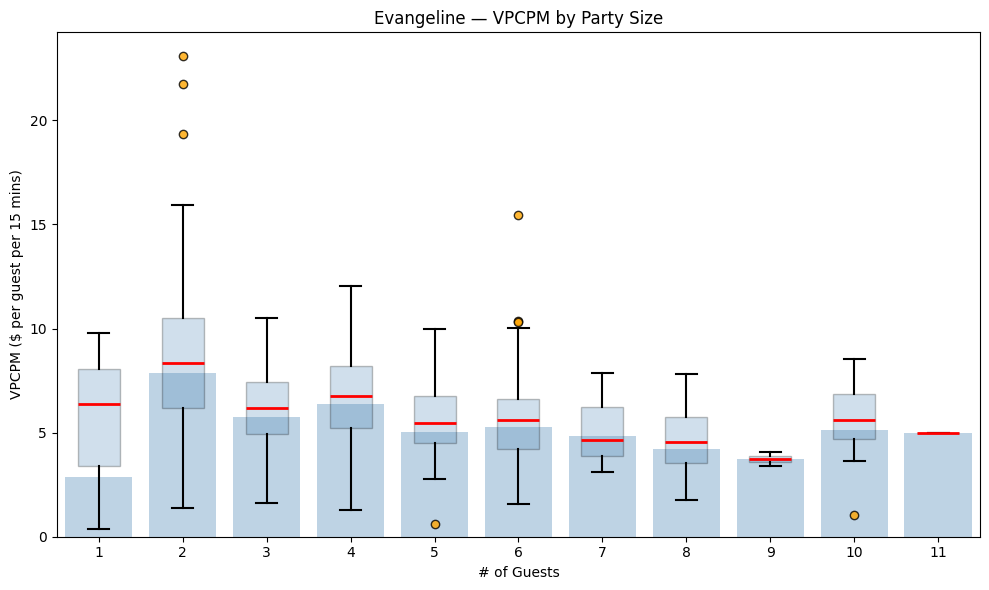

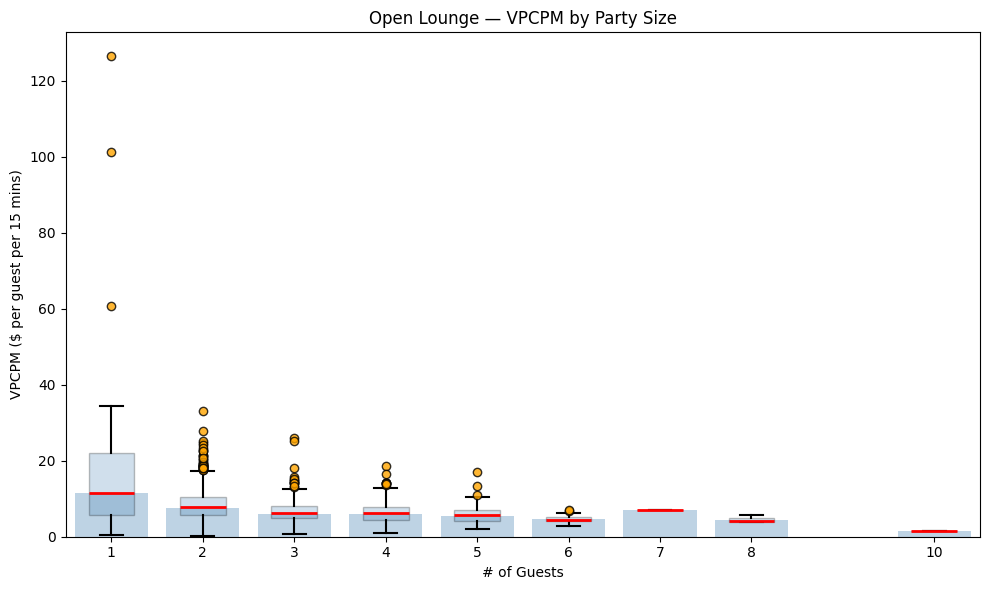

In [79]:
for section in ['Black Duck', 'Evangeline', 'Open Lounge']:
    plot_vpcpm_by_party_size(df[df['Section'] == section], f'{section} — VPCPM by Party Size')


## Table-Level Revenue Rate (TPCPM)

VPCPM normalizes by guest count, which is useful for per-seat comparisons but can obscure how much a table earns in total. **TPCPM** (Total revenue Per table, Per 15 Minutes) = `Amount / (Duration / 15)` answers the capacity-planning question directly: for a table of a given size, does a full party or a smaller one generate more $/15min? TPCPM is already on the raw dollar scale, so it needs no back-transform.


In [80]:
df['TPCPM'] = df['Amount'] / (df['Duration'] / 15)
df['LogTPCPM'] = np.log(df['TPCPM'])  # own log-scale column -- TPCPM has its own skew, distinct from VPCPM's

df.groupby(['Section', '# of Guests'])['TPCPM'].agg(['mean', 'count']).round(2)

mean  count
Section       # of Guests               
Bar           1             14.39    415
              2             18.68   1224
              3             25.59    185
              4             29.75    117
              5             38.18     12
              6             67.50     11
              8              0.95      1
Black Duck    1             11.84      4
              2             16.35    129
              3             19.35     52
              4             24.94    107
              5             31.57     35
              6             36.28     89
              7             35.25     37
              8             41.86     66
              9             52.43      3
              10            46.68      4
              12            41.88      2
              13            40.33      2
              14            32.85      1
              15            72.98     11
              16            36.61      2
              18            67.83      1
Evangeline    1              5.51      3
              2             17.24    147
              3             18.76     27
              4             27.22     91
              5             27.98     29
              6             33.90    103
              7             36.37      3
              8             37.39      6
              9             33.60      2
              10            56.55     13
              11            54.72      1
Open Lounge   1             22.70     24
              2             16.96   1603
              3             20.27    297
              4             25.55    453
              5             29.51    110
              6             28.32     15
              7             49.63      1
              8             36.35      4
              10            13.79      1
Unknown/To-Go 1             76.20     84
              2              1.49      1
              3             61.98      1
              9            120.20      1

## Section Summary & Recommendations

Ranking party sizes within each **reservation-relevant** section (Black Duck, Evangeline, Open Lounge — Bar has no reservations to optimize and is covered separately below) by a shrinkage-weighted VPCPM score. **Likely combined-table/event bookings (`Likely_Combined_Booking`) are excluded here** — see the note above and the separate section further down — so this table reflects single-table party economics, not event revenue misattributed to one table. Low-order-count party sizes get pulled toward their section's overall mean; the shrinkage strength `k` is no longer a hand-picked heuristic — it's selected per section via leave-one-out cross-validation (LOOCV), separately for VPCPM (on `LogVPCPM`) and TPCPM (on its own `LogTPCPM`, since TPCPM has its own skew/variance structure), choosing whichever `k` minimizes out-of-sample squared prediction error for that section and metric. Displayed VPCPM/TPCPM figures are back-transformed to dollars (`exp` of the log-scale shrinkage estimate). Party sizes backed by fewer than 10 orders are marked `Thin Sample` — treat those weighted estimates as illustrative, not decision-grade. 95% CIs are paused for now pending a proper significance-testing pass.

In [81]:
def select_k_loocv(section_df, value_col='LogVPCPM', group_col='# of Guests', k_grid=None):
    """Pick the shrinkage weight k that minimizes leave-one-out squared prediction error."""
    if k_grid is None:
        k_grid = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200])

    values = section_df[value_col].to_numpy()
    group_sum = section_df.groupby(group_col)[value_col].transform('sum').to_numpy()
    group_n = section_df.groupby(group_col)[value_col].transform('count').to_numpy()
    n_loo = group_n - 1
    group_mean_loo = np.divide(
        group_sum - values, n_loo,
        out=np.full_like(values, np.nan, dtype=float), where=n_loo > 0,
    )

    section_sum = values.sum()
    section_n = len(values)
    section_mean_loo = (section_sum - values) / (section_n - 1)

    valid = n_loo > 0  # can't leave-one-out a party size backed by a single order
    errors = {}
    for k in k_grid:
        w = n_loo / (n_loo + k)
        pred = w * group_mean_loo + (1 - w) * section_mean_loo
        errors[int(k)] = float(np.sum((values[valid] - pred[valid]) ** 2))

    best_k = min(errors, key=errors.get)
    return best_k, errors

RESERVATION_SECTIONS = ['Black Duck', 'Evangeline', 'Open Lounge']
# Likely combined-table/event bookings excluded here too, so k isn't fit to distorted large-party
# noise -- it should reflect single-table party-size variance, which is what it's shrinking.
single_table_df = df[~df['Likely_Combined_Booking']]

selected_k = {}
selected_k_tpcpm = {}
for section in RESERVATION_SECTIONS:
    section_df = single_table_df[single_table_df['Section'] == section]
    k, errors = select_k_loocv(section_df, value_col='LogVPCPM')
    selected_k[section] = k
    # TPCPM gets its own LOOCV-selected k on LogTPCPM -- it has its own skew/variance structure,
    # distinct from VPCPM's, so reusing VPCPM's k here isn't justified.
    k_tpcpm, errors_tpcpm = select_k_loocv(section_df, value_col='LogTPCPM')
    selected_k_tpcpm[section] = k_tpcpm

pd.DataFrame({
    'VPCPM k': pd.Series(selected_k),
    'TPCPM k': pd.Series(selected_k_tpcpm),
})

,VPCPM k,TPCPM k
Black Duck,50,8
Evangeline,20,1
Open Lounge,12,30


In [82]:
res_df = single_table_df[single_table_df['Section'].isin(RESERVATION_SECTIONS)]

summary = (
    res_df.groupby(['Section', '# of Guests'])
      .agg(**{
          'Mean LogVPCPM': ('LogVPCPM', 'mean'),
          'Mean LogTPCPM': ('LogTPCPM', 'mean'),
          'Orders': ('LogVPCPM', 'count'),
      })
      .reset_index()
)

section_means = res_df.groupby('Section')[['LogVPCPM', 'LogTPCPM']].mean()
summary['Section Mean LogVPCPM'] = summary['Section'].map(section_means['LogVPCPM'])
summary['Section Mean LogTPCPM'] = summary['Section'].map(section_means['LogTPCPM'])

# Shrinkage-weighted score: pulls low-order party sizes toward their section's overall mean.
# VPCPM and TPCPM each use their own LOOCV-selected k (see above), computed on their own log scale.
k_vpcpm = summary['Section'].map(selected_k)
k_tpcpm = summary['Section'].map(selected_k_tpcpm)
n = summary['Orders']
summary['Weighted LogVPCPM'] = (n / (n + k_vpcpm)) * summary['Mean LogVPCPM'] + (k_vpcpm / (n + k_vpcpm)) * summary['Section Mean LogVPCPM']
summary['Weighted LogTPCPM'] = (n / (n + k_tpcpm)) * summary['Mean LogTPCPM'] + (k_tpcpm / (n + k_tpcpm)) * summary['Section Mean LogTPCPM']

summary['Mean VPCPM ($)'] = np.exp(summary['Mean LogVPCPM'])
summary['Weighted VPCPM ($)'] = np.exp(summary['Weighted LogVPCPM'])
summary['Mean TPCPM ($)'] = np.exp(summary['Mean LogTPCPM'])
summary['Weighted TPCPM ($)'] = np.exp(summary['Weighted LogTPCPM'])

# Flag party sizes with a thin underlying sample so a single-order estimate isn't mistaken for a
# stable one -- shrinkage still applies, this is just a visibility flag on top of it.
THIN_SAMPLE_THRESHOLD = 10
summary['Thin Sample'] = summary['Orders'] < THIN_SAMPLE_THRESHOLD

display_cols = ['Section', '# of Guests', 'Mean VPCPM ($)', 'Weighted VPCPM ($)', 'Mean TPCPM ($)', 'Weighted TPCPM ($)', 'Orders', 'Thin Sample']
(
    summary[display_cols]
        .sort_values(['Section', 'Weighted VPCPM ($)'], ascending=[True, False])
        .round(2)
)

,Section,# of Guests,Mean VPCPM ($),Weighted VPCPM ($),Mean TPCPM ($),Weighted TPCPM ($),Orders,Thin Sample
1,Black Duck,2,7.42,7.25,14.84,14.94,129,False
0,Black Duck,1,7.02,6.84,7.02,12.52,4,True
2,Black Duck,3,6.20,6.52,18.60,18.31,45,False
3,Black Duck,4,5.83,6.35,23.34,22.12,42,False
5,Evangeline,2,7.88,7.68,15.76,15.79,147,False
6,Evangeline,3,5.59,6.18,16.77,17.32,6,True
7,Evangeline,4,5.97,6.14,23.88,23.77,27,False
4,Evangeline,1,2.85,5.74,2.85,4.70,3,True
8,Evangeline,5,4.89,5.48,24.44,24.30,26,False
9,Evangeline,6,5.26,5.43,31.58,31.45,102,False


## Large Party / Combined-Table Bookings — Known Open Issue

**Backburner issue, not resolved here.** Rows flagged `Likely_Combined_Booking` (`# of Guests > Capacity_Max`) are pulled out of the section summary above because Toast's data model ties one order to exactly one table — when staff combine multiple physical tables for a large party or private event, the whole check lands on a single "anchor" table with no record of which other tables were actually used. That's confirmed against Toast's own Orders API (a check has one table reference; combining checks moves items onto a single destination check), not something recoverable from this export after the fact.

This table is purely descriptive — total revenue and order volume for these likely-combined bookings, by section — so that revenue isn't just dropped from view. It should **not** be read as per-seat economics, since the true table count behind each of these checks is unknown. Revisit once there's a real fix (a Toast floor-plan combo-table configuration, or a staff tagging convention at merge time — see prior discussion).


In [83]:
# Restricted to the reservation-relevant sections -- Bar's `Likely_Combined_Booking` rows are a
# different, already-documented phenomenon (routine 2-guest checks on a 1-seat stool, not events;
# see the earlier overbooking discussion), so including them here would mislabel them as events.
combined_bookings = df[df['Likely_Combined_Booking'] & df['Section'].isin(RESERVATION_SECTIONS)]

combined_summary = (
    combined_bookings.groupby('Section')
      .agg(**{
          'Total Revenue ($)': ('Amount', 'sum'),
          'Orders': ('Amount', 'count'),
          'Median Guests': ('# of Guests', 'median'),
          'Max Guests': ('# of Guests', 'max'),
      })
      .reset_index()
      .sort_values('Total Revenue ($)', ascending=False)
      .round(2)
)
combined_summary


,Section,Total Revenue ($),Orders,Median Guests,Max Guests
2,Open Lounge,115138.40,674,4.0,10
0,Black Duck,92864.15,325,6.0,18
1,Evangeline,24968.20,114,4.0,11


## Bar — Revenue Reference (No Reservations)

Bar seats aren't reservable, so there's no seating decision to optimize here — this is a descriptive record only (e.g. "which party size brings in the most revenue at the bar"), not a recommendation. Note the `Duration >= 15min` filter (see the drop-rate table earlier in the notebook) removes a disproportionate share of Bar orders, so treat these figures as biased toward slower bar visits.


In [84]:
bar_df = df[df['Section'] == 'Bar']  # re-sliced here since TPCPM was added to df after the earlier bar_df/table_df split

bar_summary = (
    bar_df.groupby('# of Guests')
      .agg(**{
          'Mean VPCPM ($)': ('LogVPCPM', lambda s: np.exp(s.mean())),
          'Mean TPCPM': ('TPCPM', 'mean'),
          'Orders': ('LogVPCPM', 'count'),
      })
      .reset_index()
      .sort_values('Mean VPCPM ($)', ascending=False)
      .round(2)
)
bar_summary['Thin Sample'] = bar_summary['Orders'] < 10  # e.g. party-size 8 here is a single order -- treat as anecdote, not signal
bar_summary

,# of Guests,Mean VPCPM ($),Mean TPCPM,Orders,Thin Sample
5,6,9.12,67.50,11,False
0,1,8.89,14.39,415,False
1,2,7.48,18.68,1224,False
4,5,6.95,38.18,12,False
2,3,6.59,25.59,185,False
3,4,6.26,29.75,117,False
6,8,0.12,0.95,1,True
